# **Convolutional Neural Network(CNN) Mimarisi**




CNN, görsel tanıma görevlerinde kullanılan derin öğrenme algoritmalarıdır.

CNN’de görüntüler katmanlardan geçirilerek bir öğrenme işlemi gerçekleştirilmektedir.


CNN mimarisi, çok katmanlı bir yapıya sahiptir.


Temel anlamda bir CNN mimarisinde;



*   Convolution(Evrişim) Katmanı
*   Aktivasyon Katmanı
*   Pooling Katmanı
*   Flattening & Fully Connected(Dense) katmanları yer almaktadır


# **Convolution Layers(Evrişim Katmanı)**

---



CNN'nin temel yapı taşını oluşturmaktadır.

İlgili resmin özelliklerini algılamaktan sorumludur.

Bu katmanda, görüntüdeki düşük ve yüksek seviyeli özellikleri çıkarmak için resme bazı filtreler ya da kerneller uygulamaktayız.

CNN’de görüntüler matrislerle ifade edilmektedir. Gerekli işlemler matrisler üzerinde gerçekleştirilir. Matrislerin içerisinde yer alan değerler ise görüntüye ait piksel değerlerini içermektedir.



Bu katmanda giriş görüntüsü üzerinden öznitelik (kenar bulma, köşe bulma, görüntü üzerinde nesne bulma) çıkarımı yapılmaktadır.
Bu çıkarım filtreler ya da kerneller aracılığı ile yapılmaktadır.




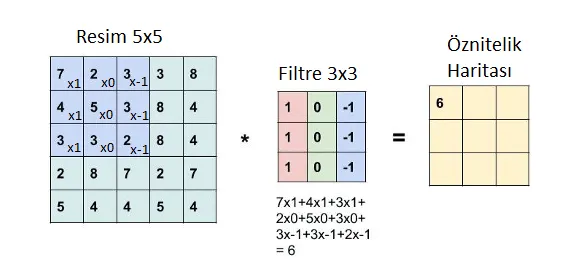

Şekilde görüldüğü üzere elimizde 5×5’lik bir görüntü matrisi ve 3×3 boyutunda bir filtre matrisi bulunmaktadır.

Bu görüntü üzerinde evrişim işleminin gerçekleştirmeden önce çıkış matrisimizin kaça kaç olacağını hesaplayalım.

Filtre matrisleri ile görüntü matrisleri çarpılır ve sonrasında toplama işlemi yapılır. Yeni değerler elde edilir.


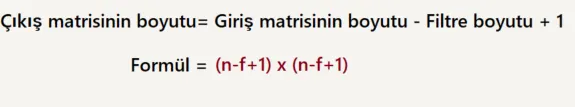

Çıkış matrisinin boyutu hesaplandıktan sonra filtre matrisi görüntü matrisinin sol üst köşesinde konumlandırılır. Ve bu iki matrisin kesişen indislerindeki değerler çarpılarak toplanır. Böylece çıkış matrisimizin ilk indeksi oluşmuş olur. Daha sonra filtre matrisi bir adım sağa kaydırılarak bu işlem devam ettirilir. Bu şekilde filtre matrisi görüntü üzerindeki yolculuğunu bitirdiğinde çıkış matrisindeki değerlerimiz hesaplanmış olacaktır. Gerekli öznitelikler bu şekilde evrişim katmanında belirlenebilir.

Düşünelim.

- O zaman evrişim katmanlarında amacımız nedir?

- Her zaman 3x3 matris boyutunda mı uygulanır?

- Bu filtrelerin kademeleri mevcut mudur?

## Stride Nedir?

Stride değeri CNN modellerinde parametre olarak değiştirilebilen bir değerdir. Bu değer filtrenin ana görsel üzerinde kaç piksel boyunca kayacağını belirler.  

Aşağıdaki gibi 7x7 boyutunda 3 kanallı bir matrise uygulanmakta olan 3x3 filtre için stride değerini 2 yaptıktan sonra çıkış matrisimizin boyutu da değişebilmektedir. Bu noktada stride değeri bizim özellik haritamızın da boyutunu düşürebilmektedir.

Stride = 2 olduğu durumda görüldüğü üzere çıkış matrisimizin boyutu da farklılık göstermektedir.

## Padding(Piksel Ekleme)




Eğer giriş matrisi ile çıkış matrisinin aynı boyutlarda olmasını istiyorsak giriş matrisine piksel ekleme (Literatürde dolgulama olarak da görülebilir) işlemi uygulamamız gerekir.

Uygulanma Sebepleri

Konvolüsyon işlemi sırasında kenar bölgeleri daha az işlem görür. Padding, bu durumu dengelemek ve kenarlardaki bilgiyi korumak için kullanılabilir.

Bazı ağlarda, özellikle görüntü segmentasyonu gibi uygulamalarda, giriş ve çıkış boyutlarının aynı olması önemlidir. Bu tür durumlarda padding genellikle kullanılır.

Özellikle derin ağlarda, boyut kaybı üst üste binen konvolüsyonlarla artar, bu yüzden padding bu kaybı önlemek için kullanılabilir.

# **Aktivasyon Katmanı**

Aktivasyon işlemi, giriş sinyali üzerinden yaptığımız doğrusal olmayan dönüşümdür. Bu dönüştürülmüş çıktı daha sonra girdi olarak bir sonraki nöron katmanına gönderilir.

Yapay sinir ağına öğrenmesi için görüntü, ses, video gibi gerçek dünya verilerini , yani karmaşık verileri öğretebilmek için aktivasyon fonksiyonlarına ihtiyaç duyarız.

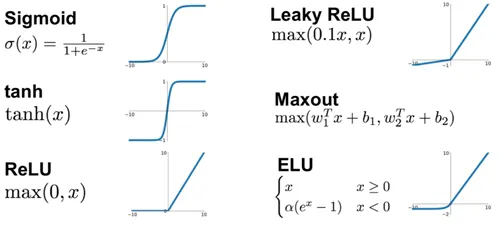

Genel olarak **Relu**, tanh, sigmoid gibi aktivasyon fonksiyonları kullanılmaktadır. Hız konusunda en iyi sonucu Relu verdiği için aktif olarak Relu kullanılmaktadır.

Çıkış katmanındaki aktivasyon fonksiyonu ise probleme göre farklılık gösterebilmektedir.

### Düşünelim

**Peki burada aktivasyon fonksiyonu ReLu görevi nedir?**

Relu aktivasyon fonksiyonu, modelin lineer olmayan özellikleri ögrenmesine yardimci olur. Görüntüler dogrusal olmayan yapilar icerebilir. Modelin karmasik olan desenleri ögrenebilmesi icin dogrusal olmamayi modelde eklemek gerekir.

**Neden Sigmoid fonksiyonunu kullanmıyoruz?**

# **Pooling Katmanı**

Feature map(Özellik haritasının) boyutunu küçültmektedir.

Amaç giriş matrisinin kanal sayısını sabit tutarak genişlik ve yükseklik bazında boyut indirgemesi yapmaktır. Avantaj olarak hesaplama karmaşıklığını azalttığını söyleyebiliriz. Bu nedenle evrişim katmanından sonra kullanılmaktadır.

### Maximum Pooling

Evrişim işleminden sonra uygulanan ortaklama işleminde maksimum ortaklama kullanıldığı taktirde filtrenin görüntü matrisi üzerindeki gezinmelerinde kesiştiği noktadaki piksel değerleri arasından maksimum olan değer seçilerek boyutu azaltılmış yeni görüntü matrisi oluşturulmuş olur.

Aşağıdaki görüntüde 4×4 boyutundaki matrise maksimum ortaklama işlemi uygulanması sonucu 2×2 boyutundaki yeni görüntü matrisi elde edilmiştir.

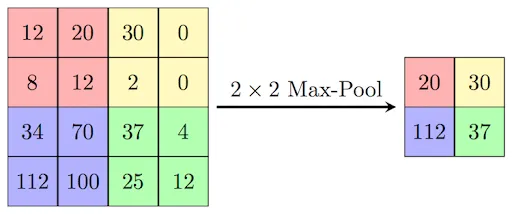

### Average Pooling



Evrişim işleminden sonra uygulanan ortaklama işleminde ortalama ortaklama kullanıldığı taktirde filtrenin görüntü matrisi üzerindeki gezinmelerinde kesiştiği noktadaki piksel değerlerinin ortalaması alınarak boyutu azaltılmış yeni görüntü matrisi oluşturulmuş olur.

Pooling özelliği:
-	Boyut küçülttüğü için hesaplama maliyetini düşürmektedir.
-	Gereksiz özelliklerden kurtarır aslında önemli özelliklerin ön plana çıkmasını sağlar.
-	Modelin daha dayanıklı hale gelmesini sağlar.


### Düşünelim

**Boyut azalırsa bilgi kaybı oluşur mu?**

**Problemin yapısı ya da veri seti boyut indirgeme kısmında önemli midir?**

Hesaplama maliyetini düsürür.
Gereksiz özellikler gidebilir ve önemli özellikler korunabilir.
Modelin daha dayanikli hale gelmesine faydali olur.

**Max.Pooling ya da Average Pooling hangi durumda uygulayabilmekteyiz?**


# **Flattening Katmanı**

Bu katmana kadar yaptığımız tüm işlemler matrisler üzerinden gerçekleştirildi. Ama bu yapılan işlemleri bir sonraki katmana aktarıp işlenebilir hale getirmek için yapay sinir ağlarının istediği format olan tek düzlemli bir vektöre dönüştürmemiz gerekiyor. Bu işlemin gerçekleştirildiği katman flattening katmanıdır.

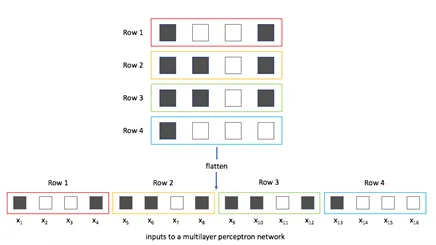


# **Fully Connected (Tam Bağlantı) Katmanı**

Bu katmanda ise flattening katmanında tek düzlemli hale dönüştürülen vektörler alınıp yapay sinir ağlarına giriş olarak verilir. Bu sayede ilgili öğrenme işlemi için süreç başlamış olur.

Literatürde Dense katmanı olarak da karşınıza çıkabilir.

Evrişim ve pooling katmanları giriş görüntüsünden özellikler çıkardıktan sonra, dense katman bu özellikleri birleştirmek ve nihai bir tahmin yapmak için kullanılabilir. Bir CNN'de dense katman genellikle son katmandır ve çıktı tahminlerini üretmek için kullanılır. Önceki katmanlardan gelen aktivasyonlar düzleştirilir ve girdilerin ağırlıklı toplamını gerçekleştiren ve nihai çıktıyı üretmek için bir aktivasyon fonksiyonu uygulayan yoğun katmana girdi olarak aktarılır.

# Bonus : Batch Normalization and Dropout

**Batch Normalization** : Batch Normalization ise bir sinir ağının katmanları arasında yapılan bir normalleştirme işlemidir.

Eğitimi hızlandırmaya ve daha yüksek öğrenme oranlarını kullanmaya olanak sağlayarak öğrenmeyi kolaylaştırılır. Genellikle evrişim katmanı ile aktivasyon katmanı arasında yer almaktadır.

**Dropout**: Dropout, rastgele seçilen belirli nöron setlerinin eğitim aşaması sırasında birimlerin (yani nöronların) yok sayılması anlamına gelmektedir. Modelin overfitting olduğu düşünülüyorsa dropout katmanı kullanılabilir.


# CNN Mimarisinin Tekrar İnceleyelim

In [ ]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
 ])

## CNN Katmanı Modelimizi Yorumlayalım

- 224 x 224 boyutlu 3 kanallı bir giriş görsel matrisi
- 1.evrişim katmanı: 32 adet 3x3 boyutlu kernel ve relu aktivasyon fonksiyonu
- Maksimum Pooling Katmanı: Boyut İndirgeme
- 2.evrişim katmanı: 64 adet 3x3 boyutlu kernel ve ReLu aktivasyon fonksiyonu
- Max.Pooling Katmanı
- 3.evrişim katmanı: 128 adet 3x3 boyutlu kernel ve ReLu aktivasyon fonksiyonu
- Flatten Katmanı: Evrişim katmanlarının çıktısını tek boyutlu bir vektöre dönüştürür.
- Dense Katmanı: Bu vektör daha sonra bir veya daha fazla fully connected (Dense) katmana beslenir. Burada, 128 nöronlu bir fully connected katmanı bulunuyor.
- 3 Sınıflandırmaya ait Softmax Aktivasyon Fonksiyonu :Son katman 3 nörondan oluşur ve softmax aktivasyon fonksiyonu kullanır. Bu, modelin 3 sınıftan birine olasılık değerleri atamasını sağlar.

### Düşünelim

- Modelim için kaç adet evrişim katmanı uygulamalıyım?

- Kernel değerlerim yeterli midir? Yeterli değilse daha derin bir özellik çıkarmak için neler yapabilirim?

- Max.Pooling katmanı uygulamam bu modelim için uygun mudur? Neden?

## CNN Avantajları:

- Özellik çıkarma: CNN'ler, ilgili özellikleri bir giriş görüntüsünden otomatik olarak çıkarma yeteneğine sahip olup, manuel özellik mühendisliği ihtiyacını azaltır.
- Spatial invariance: CNN'ler konumlarına, boyutlarına veya yönelimlerine bakılmaksızın bir görüntüdeki nesneleri tanıyabilir, bu da onları nesne tanıma görevlerine çok uygun hale getirir.
- Gürültüye karşı dayanıklı: CNN'ler genellikle gürültülü veya karmaşık görüntüleri işleyebilir, bu da onları görüntü kalitesinin değişken olabileceği gerçek dünya uygulamaları için faydalı kılar.

- Transfer Learning: CNN'ler önceden eğitilmiş modellerden yararlanarak yeni bir modeli eğitmek için gereken veri miktarını ve hesaplama kaynaklarını azaltabilir.

- Performans: CNN'ler, görüntü sınıflandırma, nesne algılama ve semantik bölümleme dahil olmak üzere bir dizi bilgisayarlı görme görevinde en son teknoloji performansı sergilemiştir.

## CNN Dezavantajları

- Hesaplama maliyeti: Derin bir CNN'nin eğitimi, hesaplama açısından pahalı olabilir ve önemli miktarda veri ve hesaplama kaynağı gerektirir.
- Overfitting(Aşırı Uyum): Derin CNN'ler, özellikle modelin yeni, görünmeyen verilere genellemek yerine eğitim verilerini ezberleyebildiği küçük veri kümeleri üzerinde eğitildiklerinde aşırı uyum sağlamaya eğilimlidir.
- Yorumlanabilirlik eksikliği: CNN'ler bir "kara kutu" modeli olarak kabul edilir ve bu da belirli bir tahminin neden yapıldığının anlaşılmasını zorlaştırır.


# Kendi Katmanlarımız ile Örneğimiz : Garbage Classification

In [ ]:
import keras
import tensorflow as tf
print("Keras Current Version:", keras.__version__, "Tensorflow Current Version:", tf.__version__)

from glob import glob
import random, os, datetime

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, metrics
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models  import Sequential, load_model
from tensorflow.keras.metrics import Accuracy, AUC

from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Keras Current Version: 3.8.0 Tensorflow Current Version: 2.18.0


## Functions

In [ ]:
def get_image_paths(root_dir, num_images=None):
    all_images = []
    for extension in ['*.jpg', '*.jpeg', '*.png']:
        all_images.extend(glob(os.path.join(root_dir, '**', extension), recursive=True))
    if num_images is None:
        return all_images
    else:
        return random.sample(all_images, min(num_images, len(all_images)))


def display_images(img_list):
    plt.figure(figsize=(15, 6))
    for i, img_path in enumerate(img_list):
        img = image.load_img(img_path)
        img = image.img_to_array(img, dtype=np.uint8)
        plt.subplot(2, 5, i + 1)
        plt.imshow(img.squeeze())
        plt.axis('off')
        plt.title(f'Image {i+1}')
    plt.tight_layout()
    plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dir_path = '/content/drive/MyDrive/Colab Notebooks/deep_learning_bootcamp/04_cnn_course_materials/datasets_and_files/Garbage classification'

In [ ]:
img_list = get_image_paths(dir_path)

print(len(img_list))

2533


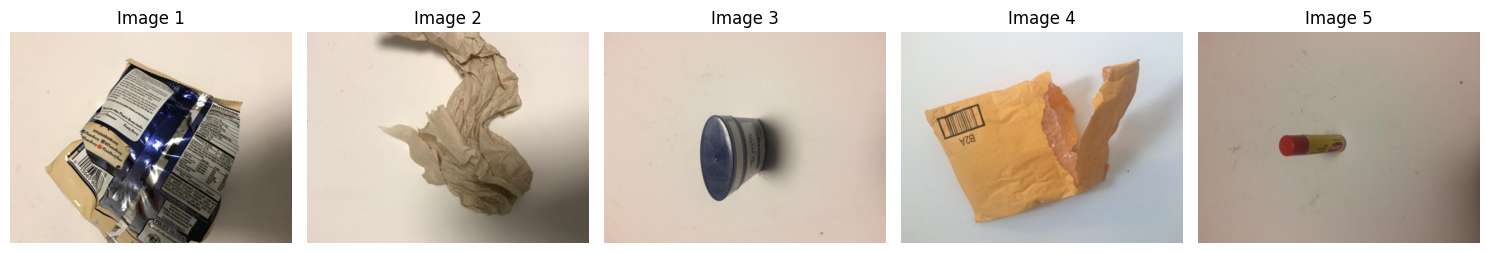

In [ ]:
display_images(img_list[0:5])

## Data Preparation & Augmentation

In [ ]:
train = ImageDataGenerator(horizontal_flip=True,
                         vertical_flip=True,
                         validation_split=0.1,
                         rescale=1./255,
                         shear_range = 0.1,
                         zoom_range = 0.1,
                         width_shift_range = 0.1,
                         height_shift_range = 0.1,)

val = ImageDataGenerator(rescale=1/255,
                        validation_split=0.1)


In [ ]:
train_generator=train.flow_from_directory(dir_path,
                                          target_size=(224, 224),
                                          batch_size=32,
                                          class_mode='categorical',
                                          subset='training')

validation_generator=val.flow_from_directory(dir_path,
                                        target_size=(224, 224),
                                        batch_size=251,
                                        class_mode='categorical',
                                        subset='validation')

Found 2282 images belonging to 6 classes.
Found 251 images belonging to 6 classes.


## Model

In [ ]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])


metrics = [
    "accuracy",
    AUC(name='auc', multi_label=True)]

# optimizer = SGD(learning_rate=0.001, momentum=0.9)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=metrics)


early_stopping = EarlyStopping(monitor='val_loss',
                           patience=10,
                           verbose=1,
                           restore_best_weights=True)

model_checkpoint = ModelCheckpoint(filepath='garbage_model.keras',
                             monitor='val_loss',
                             save_best_only=True,
                             save_weights_only=False,
                             verbose=1)

In [ ]:
start_time = datetime.datetime.now()

history = model.fit(train_generator,
                    epochs=50,
                    validation_data=validation_generator,
                    callbacks=[early_stopping, model_checkpoint])

end_time = datetime.datetime.now()
total_duration = end_time - start_time
print("Trainin Time:", total_duration)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.2576 - auc: 0.5599 - loss: 4.6788 
Epoch 1: val_loss improved from inf to 1.51652, saving model to garbage_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 1379s 19s/step - accuracy: 0.2584 - auc: 0.5608 - loss: 4.6481 - val_accuracy: 0.3705 - val_auc: 0.7260 - val_loss: 1.5165
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.4179 - auc: 0.7299 - loss: 1.4438
Epoch 2: val_loss did not improve from 1.51652
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 407ms/step - accuracy: 0.4180 - auc: 0.7301 - loss: 1.4437 - val_accuracy: 0.3705 - val_auc: 0.7494 - val_loss: 1.5643
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.4659 - auc: 0.7838 - loss: 1.3533
Epoch 3: val_loss improved from 1.51652 to 1.29775, saving model to garbage_model.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 418ms/step - accuracy: 0.4660 - auc: 0.7839 - loss: 1.3530 - val_accuracy: 0.4582 - val_auc: 0.8088 - val_loss: 1.2978
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━

## Model Performance

In [ ]:
val_loss, val_accuracy, val_auc = model.evaluate(validation_generator, verbose=0)
print(f"Loss: {val_loss}")
print(f"Accuracy: {val_accuracy}")
print(f"AUC: {val_auc}")

Loss: 1.0147781372070312
Accuracy: 0.6215139627456665
AUC: 0.8908205032348633


## Prediction

In [ ]:
waste_labels = {0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic', 5: 'trash'}

In [ ]:
im_dir = "/content/drive/MyDrive/Colab Notebooks/04_cnn_course_materials/datasets_and_files/Garbage classification"

In [ ]:
images_paths = [im_dir + "/metal/metal10.jpg", im_dir + "/glass/glass104.jpg", im_dir + "/plastic/plastic100.jpg", im_dir + "/trash/trash103.jpg"]

In [ ]:
garbage_model = load_model('/content/garbage_model.keras')

In [ ]:
def preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)

    img_array = image.img_to_array(img) / 255.0

    img_array = np.expand_dims(img_array, axis=0)

    return img, img_array

In [ ]:
def prediction_probs(img_array, model, waste_labels):

    predictions = model.predict(img_array, verbose = 0)

    predicted_class_idx = np.argmax(predictions[0])

    predicted_class = waste_labels.get(predicted_class_idx, 'Unknown')

    max_probability = np.max(predictions[0])

    return max_probability, predicted_class

In [ ]:
def display_images(image_paths, model, waste_labels):
    # dynamic display
    num_images = len(image_paths)
    num_cols = 4
    num_rows = (num_images + num_cols - 1) // num_cols
    plt.figure(figsize=(num_cols * 5, num_rows * 5))

    for i, path in enumerate(image_paths):
        img, img_array = preprocess_image(path)

        probability, predicted_class = prediction_probs(img_array, model, waste_labels)

        ax = plt.subplot(num_rows, num_cols, i + 1)
        img = image.img_to_array(img)
        plt.imshow(img.astype('uint8'))
        plt.title(f"Max Probability: {probability:.2f}\nPredicted Class: {predicted_class}")
        plt.axis('off')
    plt.show()

In [ ]:
random_images_path = get_image_paths(im_dir, 10)

# Pretrained CNN Modelleri

Çeşitli görsel tanıma görevlerinde kullanılmak üzere hazırlanmış olup eğitilmiş ve optimize edilmiş modelleri ifade etmektedir.

Modelleri kullanmanın avantajları nelerdir?

- Kaynak ve Zaman Maliyeti
- Performans
- Özelleştirme ve Adaptasyon

Bu modellere erişebilmek için kaynaklar şunlardır:

**Keras Applications:** Önceden öğrenmiş birçok derin öğrenme modelini içerir. Özellikle görüntü sınıflandırma ve transfer learning işlemleri için oldukça iyidir.

**TorchVision:** Pytourch un bir eklentisidir. Yine içerisinde görüntü işleme için verisetleri, model yapıları, önceden eğitilmiş modelleri barındırır.

**Keras CV: (CV:computer vısıon)** Görüntü işleme sureclerını daha genel cercevesı ıle ele alır. Katmanları olusturmak , verı arttırmak, loss fonksıyonları goruntu ısleme surecını butunsel olarak bır pıpelıne olarak ele alan bır kutuphanedır

**Open CV DNN:** Open CV nin derin ogrenme modellerı ıcın ıhtıyac duyulabılecek olan bazı modullerı barındırdıgı moduldur. Daha dusuk sevıyede yanı kullanımı daha kolay olabılecek performans odaklı goruntu ısleme ve derın ogrenme ıslemlerını yapmak ıcın oldukca uygundur.

**Hugging Face:** Görüntü işleme ve object detectıon ıcın keras ve torchvısıon, daha cok dogal dıl ısleme tarafında merkezi bir pozısyondadır.

## AlexNet

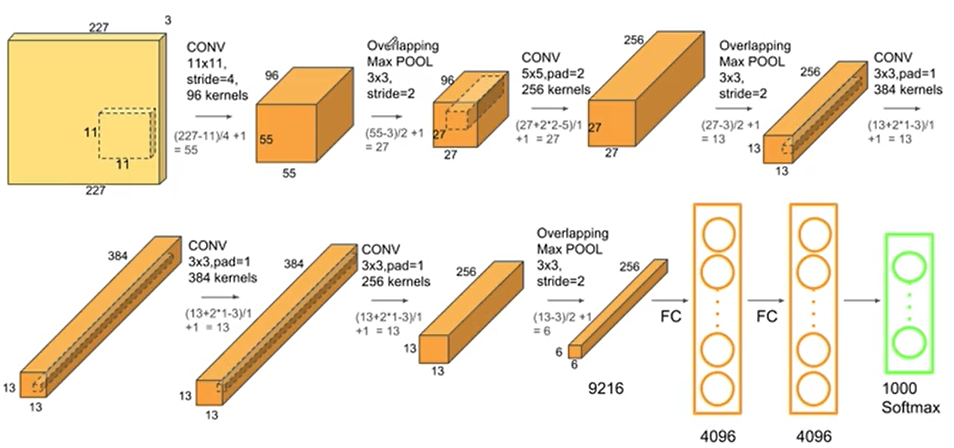

CNN ve Derin öğrenme mimarisinin yaygınlaşmasında önemli rol oynamıştır.

8 katmandan oluşmaktadır. ( 5 evrişim , 3 dense katman)

Modelin genelleme yeteneğini arttırmak için veri arttırma teknikleri kullanılmıştır.

GPU kullanılmasında önemli rol oynamıştır.



Bilgisayarla görme uygulamaları, nesne tanıma ve görüntü tabanlı öneri sistemlerinde yaygın olarak kullanılır.

Büyük veri setlerinde iyi performans gösterir. Ancak, ağın derinliği ve katman sayısı göz önüne alındığında, eğitim süresi uzun olabilir ve bu nedenle güçlü donanım (örneğin, GPU'lar) gerektirir.

## VGG(Visual Geomertry Group)

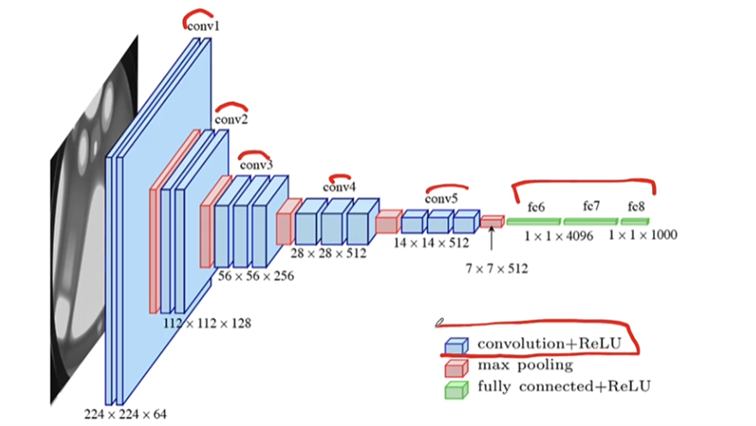

  Standartlaştırılmış Evrişim Blokları : Standartlastırılmıs evrısım blokları, yanı oncekı yapılara gore belırlı bır standart uyguladıgından dolayı daha homojen bır yapı ortaya cıkarıyor. Sadece 3*3 boyutlarında kucuk evrısım fıltrelerı kullanıyor.

  Deeper Structure(More Parameters)

  Weight Initilisation Method: Ağırlık baslatma yontemı olarak Xaiver yöntemi kullanılıyor

Aktivasyon Fonksiyonu


## GoogleNet(Inception v1)

Fıltreleme ve pooling operasyonlarını bırlestıren bır modul olan Inceptıon Modulu.
Bu moduller sayesinde aynı anda farklı ozellıktekı ölçekleri işlemeye imkan sağlıyor ve böylece hesaplama verimliliğini arttırmaktadır.

1*1 evrısımlı katmanlar kullanılıyor.

Daha buyuk katmanlardan once kullanılan bu bırebırlık evrısımlı katmanları boyut ındırgeme ve agın verımlılıgını arttırma ımkanı saglıyor.

Toplam 22 katmanlık derin bir mimari içermektedir.

Kucuk fıltreler ve coklu yollar:  Burada bırden fazla yol var boylece farklı olcekler ve farklı boyutlardaki ozellıklerı de yakalayabılıyor olmakla ılgılı bır durumu var.



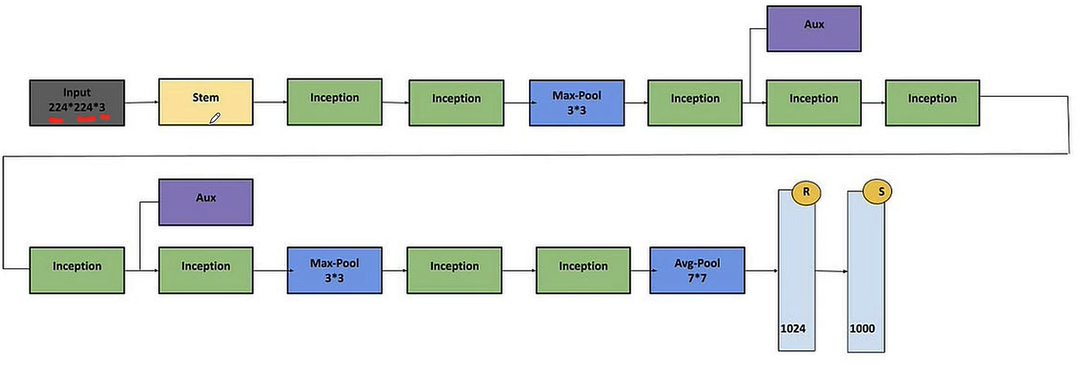

Yardımcı sınıflandırıcılar adı verılen egıtım sırasında modelın orta katmanlarına yerlestırılen sınıflandırıcılar var.

Global Average Poolıng yontemı kullanılmıs. Son katmanda tam baglantılı katman yerıne kullanılan bır poolıng yontemı. Modelın son ozellık harıtasındakı her bır kanal ıcın ortalama degerı alır. Bu da modelın agırlık sayısını buyuk bır olcude azaltmaya katkı saglar.

Inception mimarisi, büyük veri setlerinde oldukça etkili olabilir. Karmaşık veri setlerinde ve yüksek hesaplama gücü gerektiren görevlerde tercih edilir.

Küçük veri setlerinde Inception mimarisi, transfer learning+ fine tuning yöntemleri ile birlikte kullanıldığında etkili olabilir.

## ResNet(Residual Network)

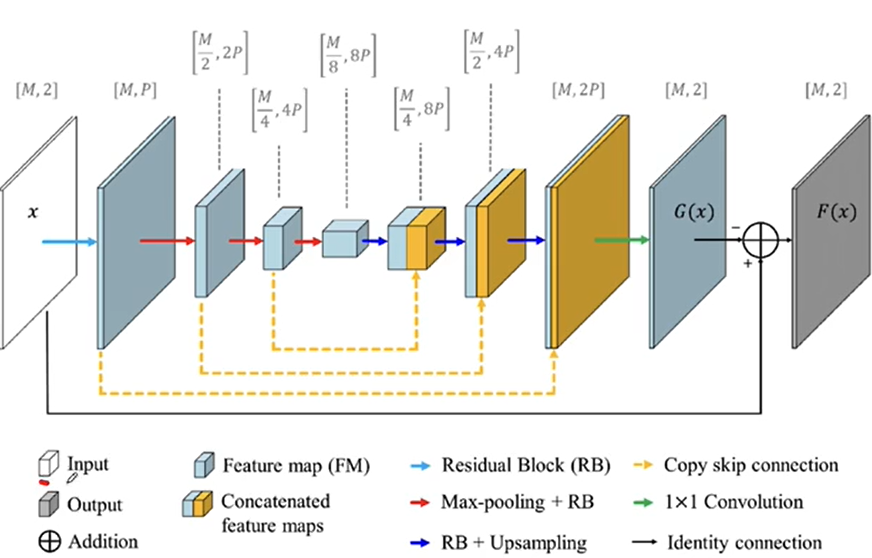

Özellikle Derin Ağların egıtımı sırasında karsılasılan kaybolan gradyan problemıne cozum sunmaktır. 152 katmandan olusuyor.

Skip connections yapısı ve artık ıfadesı. Resnetın atlamalı baglantıları var. Bu baglantılar bır katmandan cıkan gırdının bır sonrakı katmana dogrudan degıl de bırkac katman atlayarak ıletılmesını saglar. Bu atlamalı baglantılar sayesınde agın ılerı katmanlarına bılgı tasınır

Residual Learning: kalıntı ogrenme. gırıs verısı ıle cıktı arasındakı farkı ogrenmeye calısır. Boylece bu modelın daha derın olmasına ragmen ogrenılmesını kolaylastırır ve kaybolan gradyan problemıne katkı saglar.

deep architecture: daha derın mımarı. farklı farklı versıyonlarda farklı farklı mımarıler var. 34, 50, 152 katmanlı gıbı.  

block desıgn: blok tasarımı. bu ozellık aktarma ıslemını kolaylastıran blok tabanlı tasarım kullanılmıstır. Bu bloklarda ozellıkler uzerınde belırlı ıslemler gerceklestırılır ve bu ıslemler atlamalı baglantılar yoluyla taşınır.

low complexıty: daha az hesaplama karmasıklıgına sahıptır. Bundan dolayı daha ıyı performans gosterır. Ve bu ıfade ettıgımız atlamalı baglantılar sayesınde her katman daha kucuk bır degısıklıgı modellemek ıcın egıtılır bu da egıtımı daha derın bır hale getırır.

Küçük veri setlerinde ResNet kullanımı, transfer öğrenme veya veri artırma gibi tekniklerle desteklendiğinde başarılı olabilir. ResNet'in modüler yapısı, küçük veri setlerinde de iyi çalışmasını sağlar.

## MobileNet


MobileNet mimarisi, özellikle mobil ve gömülü cihazlar gibi sınırlı hesaplama kaynaklarına sahip platformlar için optimize edilmiş bir derin öğrenme modelidir.

MobileNet, derinlik-ağırlıklı evrişim (depthwise separable convolutions) gibi inovatif teknikler kullanarak, parametre sayısını ve hesaplama maliyetini önemli ölçüde azaltırken, yüksek doğruluk elde etmeyi amaçlar.

MobileNet, mobil ve gömülü cihazlarda görüntü sınıflandırma ve nesne algılama gibi görevler için optimize edilmiştir. Hafif ve düşük hesaplama maliyetine sahip bir mimari sunar.

MobileNet, küçük veri setleri için özellikle uygundur, çünkü daha az parametre içerir ve aşırı uyum riskini azaltır. Mobil cihazlarda veri kısıtlılığı olan uygulamalar için idealdir

# Transfer Learning and Fine Tuning

Önceden eğitilmiş bir modelin bilgi ve deneyimini, bir görev veya veri kümesinden farklı bir görev veya veri kümesine uygulama sürecidir.

Transfer learning, genel bir modeli belirli bir göreve adapte olmak için bir başlangıç noktası sağlar.

Fine tuning ise bu modelin o görevde en iyi sonucu ya da başarıyı vermesi için özelleştirmeler yapma imkanı sağlar.

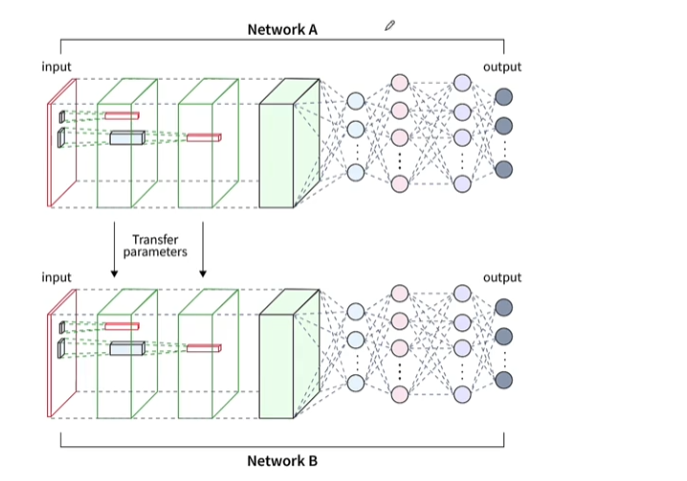

Burada belirli parametreleri ya da yapıları kendi çalışmamıza transfer ederek modellerin güçlü yanlarını kendimize aktarabiliriz.

Hinton un geliştirmiş olduğu modelleri, kendi çalışmalarımıza uyarlamaktır.

Görüntülerden özellik çıkarmak ve tahminde bulunmak

Kendi problemlerimize özel olarak çözüm üretmek


Fine Tuning Tekniklerimiz:

- Feature Extractor(Özellik çıkarmak)
- Full Network Fine Tuning: Hiçbir katman dondurulmaz temel mimari baz alınır.Bu temel mimari veri setine uygun halde özelleştirilir.
- Katmanların dondurulması(Frozen layers)
- Gradual Unfreezing: Kademelı/asamalı bır sekılde modelın katmanlarını donmus durumdan cıkartmaktır. Bu yaklasım ıterasyonlar devam ettıkce ve modelın performansı ızlenerek gıderek daha fazla katmanın egıtıme dahıl edılmesıdı

# Fine Tuning with MobileNetV2 Backbone


In [ ]:
import keras
import tensorflow as tf
print("Keras Current Version:", keras.__version__, "Tensorflow Current Version:", tf.__version__)

from glob import glob
import random, os, datetime

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, metrics
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models  import Sequential, load_model
from tensorflow.keras.metrics import Accuracy, AUC

from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# Tensorflow ve Keras kütüphaneleri
import tensorflow as tf
from keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input as preprocess_input_mobilenetv2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Conv2D, Flatten, MaxPooling2D, Dropout, SpatialDropout2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
def plot_training_history(history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy'):

    #Loss
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_loss], label='Training Loss')
    plt.plot(history.history[val_loss], label='Validation Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Metrics
    plt.figure(figsize=(10, 5))
    plt.plot(history.history[train_metric], label=f"Training: {train_metric}")
    plt.plot(history.history[val_metric], label=f"Validation: {val_metric}")
    plt.title(f'Training and Validation {train_metric} Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel(f'train_metric')
    plt.legend()
    plt.show()

# Frozen Layers


## MobilenetV2 Backbone

In [ ]:
mobilenet_backbone = MobileNetV2(weights='imagenet',

                                 include_top=False,

                                 input_shape=(224, 224, 3))

#alpha=1.0
#classes

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
mobilenet_backbone.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
block_count = 0
for layer in mobilenet_backbone.layers:
    if isinstance(layer, tf.keras.layers.Conv2D) and 'expand' in layer.name:
        block_count += 1

print(f"Number of logical 'blocks' in MobileNetV2: {block_count}")

Number of logical 'blocks' in MobileNetV2: 17


In [ ]:
for layer in mobilenet_backbone.layers:
    print(layer.name, layer.trainable)

input_layer_1 True
Conv1 True
bn_Conv1 True
Conv1_relu True
expanded_conv_depthwise True
expanded_conv_depthwise_BN True
expanded_conv_depthwise_relu True
expanded_conv_project True
expanded_conv_project_BN True
block_1_expand True
block_1_expand_BN True
block_1_expand_relu True
block_1_pad True
block_1_depthwise True
block_1_depthwise_BN True
block_1_depthwise_relu True
block_1_project True
block_1_project_BN True
block_2_expand True
block_2_expand_BN True
block_2_expand_relu True
block_2_depthwise True
block_2_depthwise_BN True
block_2_depthwise_relu True
block_2_project True
block_2_project_BN True
block_2_add True
block_3_expand True
block_3_expand_BN True
block_3_expand_relu True
block_3_pad True
block_3_depthwise True
block_3_depthwise_BN True
block_3_depthwise_relu True
block_3_project True
block_3_project_BN True
block_4_expand True
block_4_expand_BN True
block_4_expand_relu True
block_4_depthwise True
block_4_depthwise_BN True
block_4_depthwise_relu True
block_4_project True
b

In [ ]:
for layer in mobilenet_backbone.layers[-11:]:
    print(layer.name, layer.trainable)

block_16_expand True
block_16_expand_BN True
block_16_expand_relu True
block_16_depthwise True
block_16_depthwise_BN True
block_16_depthwise_relu True
block_16_project True
block_16_project_BN True
Conv_1 True
Conv_1_bn True
out_relu True


In [ ]:
for layer in mobilenet_backbone.layers:
    layer.trainable = False

In [ ]:
for layer in mobilenet_backbone.layers:
    print(layer.name, layer.trainable)

input_layer_1 False
Conv1 False
bn_Conv1 False
Conv1_relu False
expanded_conv_depthwise False
expanded_conv_depthwise_BN False
expanded_conv_depthwise_relu False
expanded_conv_project False
expanded_conv_project_BN False
block_1_expand False
block_1_expand_BN False
block_1_expand_relu False
block_1_pad False
block_1_depthwise False
block_1_depthwise_BN False
block_1_depthwise_relu False
block_1_project False
block_1_project_BN False
block_2_expand False
block_2_expand_BN False
block_2_expand_relu False
block_2_depthwise False
block_2_depthwise_BN False
block_2_depthwise_relu False
block_2_project False
block_2_project_BN False
block_2_add False
block_3_expand False
block_3_expand_BN False
block_3_expand_relu False
block_3_pad False
block_3_depthwise False
block_3_depthwise_BN False
block_3_depthwise_relu False
block_3_project False
block_3_project_BN False
block_4_expand False
block_4_expand_BN False
block_4_expand_relu False
block_4_depthwise False
block_4_depthwise_BN False
block_4_d

In [ ]:
for layer in mobilenet_backbone.layers[-11:]:
    layer.trainable = True

In [ ]:
for layer in mobilenet_backbone.layers:
    print(layer.name, layer.trainable)

input_layer_1 False
Conv1 False
bn_Conv1 False
Conv1_relu False
expanded_conv_depthwise False
expanded_conv_depthwise_BN False
expanded_conv_depthwise_relu False
expanded_conv_project False
expanded_conv_project_BN False
block_1_expand False
block_1_expand_BN False
block_1_expand_relu False
block_1_pad False
block_1_depthwise False
block_1_depthwise_BN False
block_1_depthwise_relu False
block_1_project False
block_1_project_BN False
block_2_expand False
block_2_expand_BN False
block_2_expand_relu False
block_2_depthwise False
block_2_depthwise_BN False
block_2_depthwise_relu False
block_2_project False
block_2_project_BN False
block_2_add False
block_3_expand False
block_3_expand_BN False
block_3_expand_relu False
block_3_pad False
block_3_depthwise False
block_3_depthwise_BN False
block_3_depthwise_relu False
block_3_project False
block_3_project_BN False
block_4_expand False
block_4_expand_BN False
block_4_expand_relu False
block_4_depthwise False
block_4_depthwise_BN False
block_4_d

## Training

In [ ]:
x = GlobalAveragePooling2D()(mobilenet_backbone.output)

In [ ]:
x = Dense(6, activation='softmax')(x)

In [ ]:
fine_tuning_model = Model(inputs=mobilenet_backbone.input, outputs=x)

In [ ]:
metrics = ["accuracy", AUC(name='auc', multi_label=True)]

In [ ]:
from tensorflow.keras.optimizers import SGD

In [ ]:
optimizer=SGD(learning_rate=0.0001, momentum=0.9, nesterov=True)

In [ ]:
fine_tuning_model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=metrics)

early_stopping = EarlyStopping(monitor='val_loss',
                               patience=10,
                               restore_best_weights=True,
                               verbose=1)


model_checkpoint = ModelCheckpoint('mobilenetv2_finetuned.keras',
                                   monitor='val_loss',
                                   save_best_only=True,
                                   save_weights_only=False,
                                   verbose=1)

In [ ]:
start_time = datetime.datetime.now()

fine_tuning_model_history = fine_tuning_model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    callbacks=[early_stopping, model_checkpoint]
)

end_time = datetime.datetime.now()

total_duration = end_time - start_time
print("Training Time:", total_duration)

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.1775 - auc: 0.5234 - loss: 1.9923
Epoch 1: val_loss improved from inf to 1.41275, saving model to mobilenetv2_finetuned.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 79s 887ms/step - accuracy: 0.1793 - auc: 0.5250 - loss: 1.9883 - val_accuracy: 0.4582 - val_auc: 0.7588 - val_loss: 1.4127
Epoch 2/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.5828 - auc: 0.8263 - loss: 1.2071
Epoch 2: val_loss improved from 1.41275 to 1.20434, saving model to mobilenetv2_finetuned.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 36s 461ms/step - accuracy: 0.5833 - auc: 0.8270 - loss: 1.2056 - val_accuracy: 0.5538 - val_auc: 0.8439 - val_loss: 1.2043
Epoch 3/100
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.6638 - auc: 0.8941 - loss: 0.9841
Epoch 3: val_loss improved from 1.20434 to 1.11577, saving model to mobilenetv2_finetuned.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 468ms/step - accuracy: 0.6642 - auc: 0.8943 - loss: 0.9833 - val_accuracy: 0.5817 

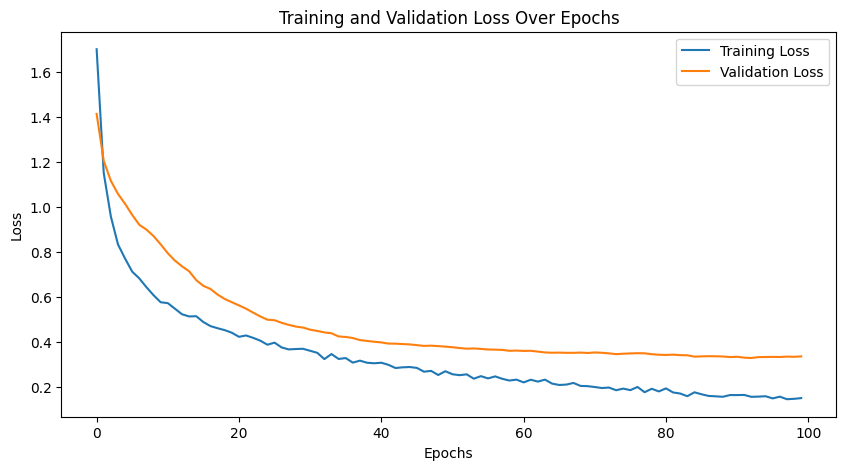

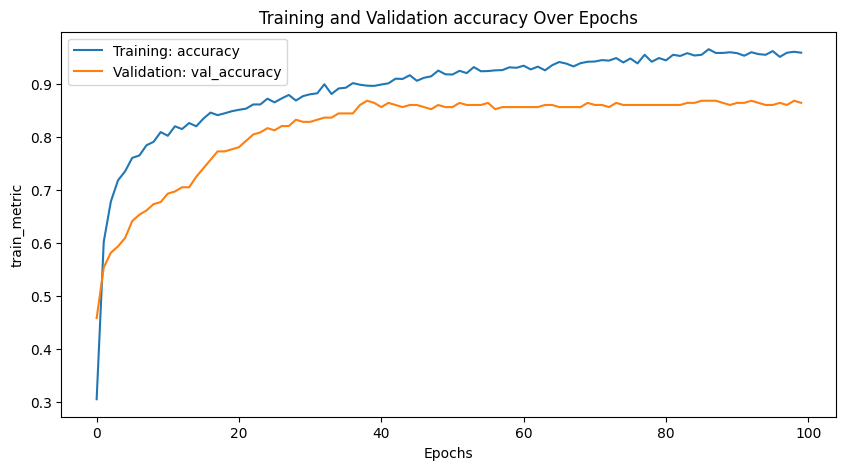

In [ ]:
plot_training_history(fine_tuning_model_history, train_loss='loss', train_metric='accuracy', val_loss='val_loss', val_metric='val_accuracy')

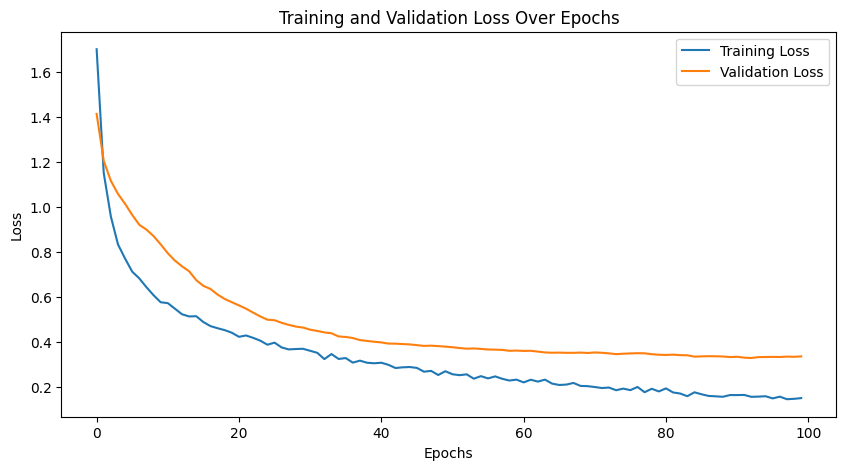

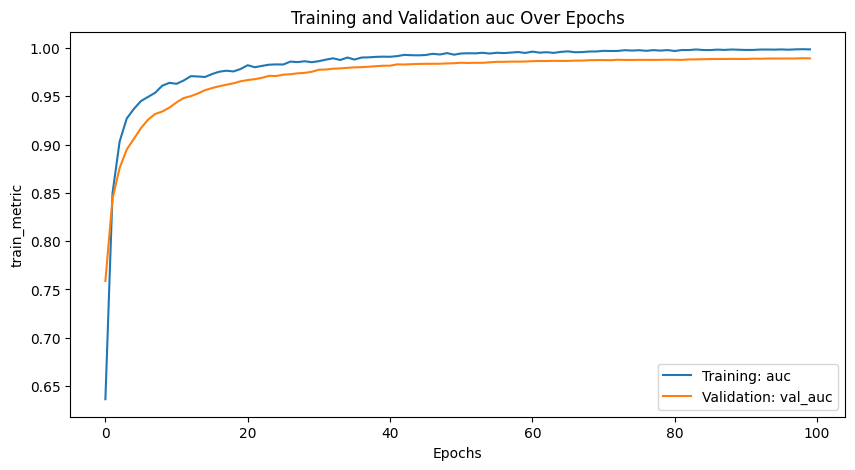

In [ ]:
plot_training_history(fine_tuning_model_history, train_loss='loss', train_metric='auc', val_loss='val_loss', val_metric='val_auc')

In [ ]:
val_loss, val_accuracy, val_auc = fine_tuning_model.evaluate(validation_generator, verbose=0)
print(f"Loss: {val_loss}")
print(f"Accuracy: {val_accuracy}")
print(f"AUC: {val_auc}")

Loss: 0.33028873801231384
Accuracy: 0.8685259222984314
AUC: 0.9887925982475281


In [ ]:
def preprocess_mobilenet(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input_mobilenetv2(img_array)
    return img_array

def predict_mobilenet(model, img_array, class_labels):
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    predicted_class = class_labels[predicted_class_idx]
    probability = np.max(predictions[0])
    return predicted_class, probability

def visualise_preds_mobilenet(model, image_paths, class_labels, visualize=False):
    results = {}
    for img_path in image_paths:
        img_array = preprocess_mobilenet(img_path)
        label, probability = predict_mobilenet(model, img_array, class_labels)
        results[img_path] = (label, probability)
        if visualize:
            plt.figure(figsize=(5, 5))
            plt.imshow(image.load_img(img_path))
            plt.title(f"Predicted: {label} ({probability:.2f}%)")
            plt.axis('off')
            plt.show()

    return results

In [ ]:
garbage_full_tuned_model = load_model('/content/mobilenetv2_finetuned.keras')

In [ ]:
img_list = get_image_paths(dir_path, 10)

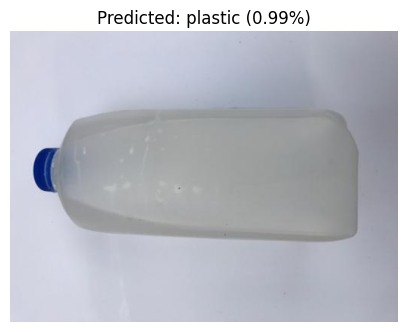

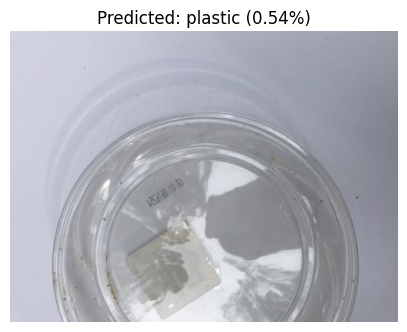

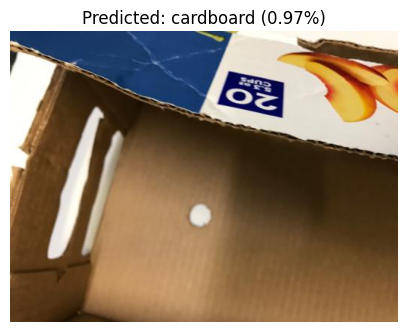

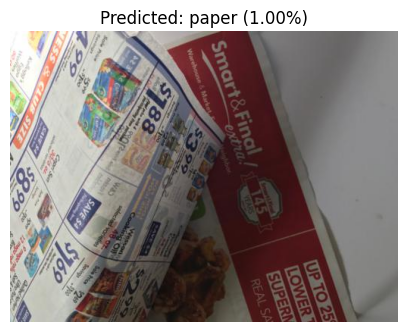

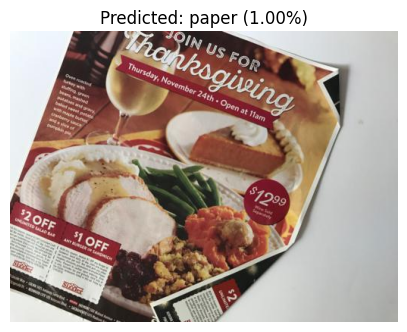

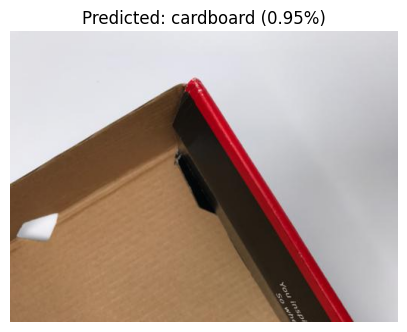

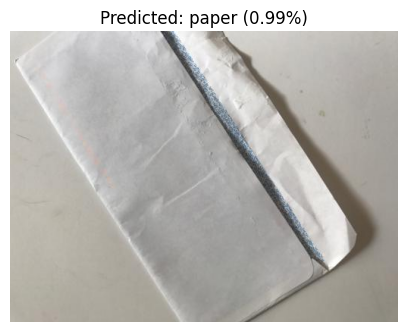

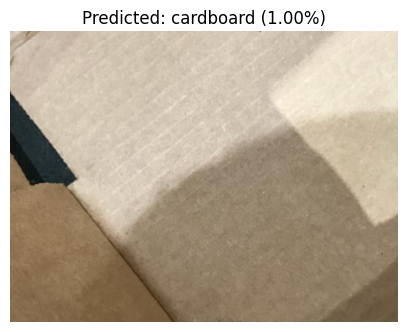

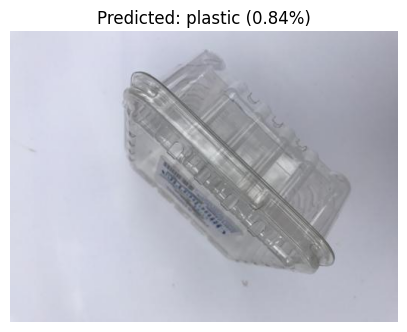

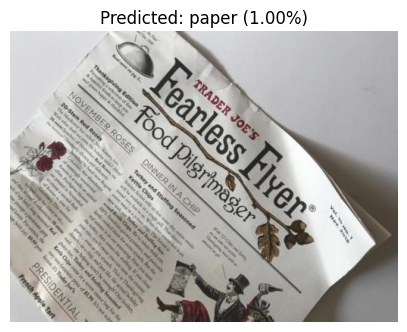

In [ ]:
predicted_classes = visualise_preds_mobilenet(garbage_full_tuned_model, img_list, waste_labels, True)